# Phase 3 checkpoint: the heat engine, validated

COOLBLOCK-BUILD-PLAN.md §6.1: the cloud-masked Landsat composite (A1), TsHARP
statistical downscaling 30m -> 10m (A2), and the three-check go/no-go
validation gate (A3). Every number below is computed live from the Phase 1
cache -- nothing here is asserted without the code that produced it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from engine.thermal.composite import build_composite, load_landsat_cube, scene_clear_fraction
from engine.thermal.downscale import run_downscaling
from engine.thermal.validate import run_validation

ds = load_landsat_cube()
print(f"{ds.sizes['time']} cached Landsat scenes, summer 2021-2025")

63 cached Landsat scenes, summer 2021-2025


## A1 -- the cloud-masked composite

clear-pixel fraction per scene: min=0.00 mean=0.92 max=1.00
scenes with <10% clear pixels (heavily clouded, still included -- masked per-pixel): 3/63



composite: 4624/4624 valid pixels, range 51.0-58.1 degC, mean 55.9 degC


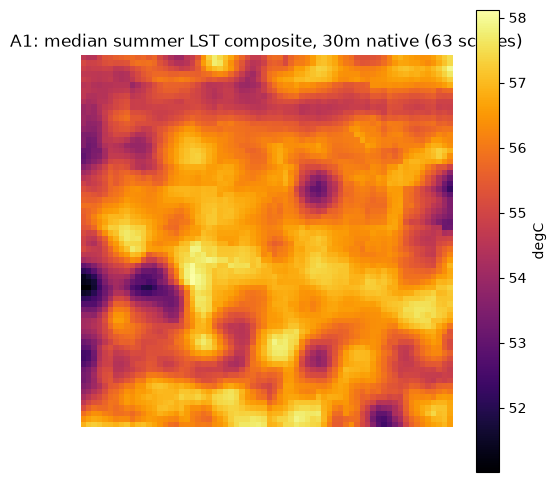

In [2]:
clear_frac = scene_clear_fraction(ds)
print(f"clear-pixel fraction per scene: min={float(clear_frac.min()):.2f} mean={float(clear_frac.mean()):.2f} max={float(clear_frac.max()):.2f}")
print(f"scenes with <10% clear pixels (heavily clouded, still included -- masked per-pixel): {int((clear_frac < 0.1).sum())}/{ds.sizes['time']}")

composite = build_composite(ds)
valid = composite.values[np.isfinite(composite.values)]
print(f"\ncomposite: {valid.size}/{composite.size} valid pixels, range {valid.min():.1f}-{valid.max():.1f} degC, mean {valid.mean():.1f} degC")

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(composite.values, cmap="inferno")
ax.set_title("A1: median summer LST composite, 30m native (63 scenes)")
ax.axis("off")
fig.colorbar(im, label="degC")
plt.show()

## A2 -- TsHARP downscaling, 30m -> 10m

Spatial cross-validation (5-fold, spatially blocked -- not random shuffle):
  R^2   = 0.215
  RMSE  = 0.936 degC
  n training pixels (30m) = 4556

10m surface: 39798 valid px, range 51.0-58.6 degC
uncertainty (q90-q10): mean 1.94 degC, range 0.09-4.93 degC


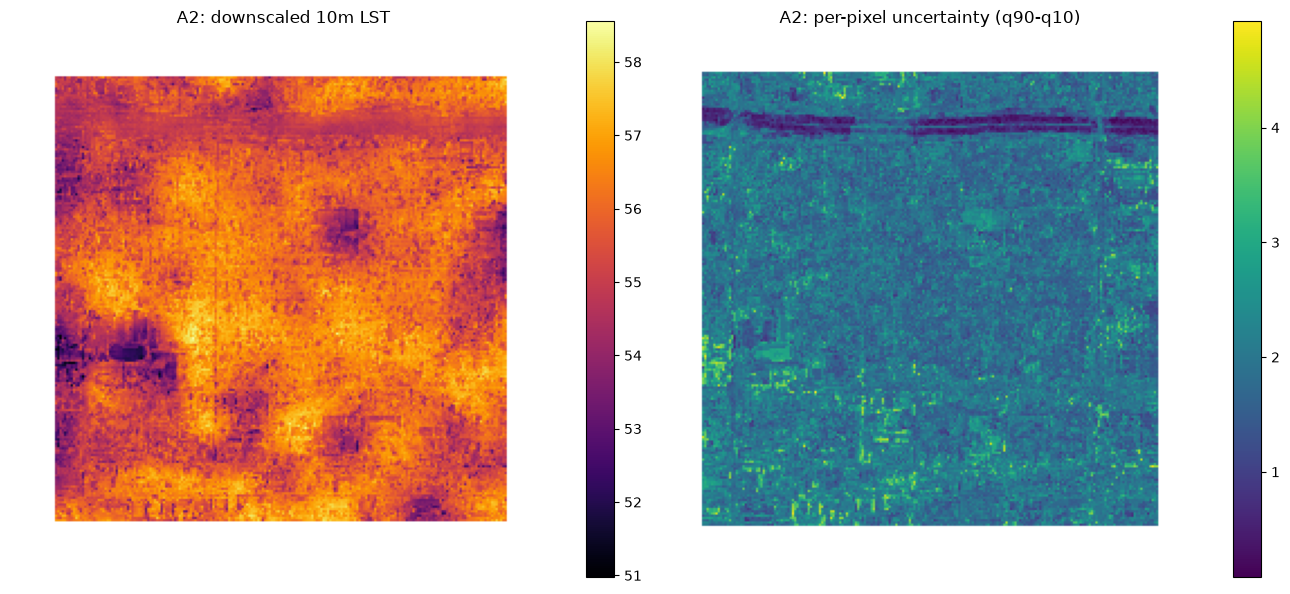

In [3]:
result = run_downscaling()
print("Spatial cross-validation (5-fold, spatially blocked -- not random shuffle):")
print(f"  R^2   = {result.r2_cv:.3f}")
print(f"  RMSE  = {result.rmse_cv:.3f} degC")
print(f"  n training pixels (30m) = {result.n_training_pixels}")

lst_valid = result.lst_10m.values[np.isfinite(result.lst_10m.values)]
unc_valid = result.uncertainty_10m.values[np.isfinite(result.uncertainty_10m.values)]
print(f"\n10m surface: {lst_valid.size} valid px, range {lst_valid.min():.1f}-{lst_valid.max():.1f} degC")
print(f"uncertainty (q90-q10): mean {unc_valid.mean():.2f} degC, range {unc_valid.min():.2f}-{unc_valid.max():.2f} degC")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
im0 = axes[0].imshow(result.lst_10m.values, cmap="inferno")
axes[0].set_title("A2: downscaled 10m LST")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(result.uncertainty_10m.values, cmap="viridis")
axes[1].set_title("A2: per-pixel uncertainty (q90-q10)")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

## A3 -- the go/no-go validation gate

In [4]:
verdict = run_validation()

print("1) Station correlation (LST at centroid vs. Open-Meteo air temp, per scene):")
print(f"   r = {verdict.station.pearson_r:.3f}  (n={verdict.station.n_scenes} scenes, threshold >= 0.3)")
print(f"   mean LST - air temp = {verdict.station.mean_lst_minus_air_c:.1f} degC (expected: positive, urban daytime)")

print("\n2) Land-cover contrast (parking-lot polygons vs. park/grass polygons):")
print(f"   parking mean = {verdict.landcover.parking_mean_c:.1f} degC (n={verdict.landcover.n_parking_polygons} polygons)")
print(f"   park mean    = {verdict.landcover.park_mean_c:.1f} degC (n={verdict.landcover.n_park_polygons} polygons)")
print(f"   contrast     = {verdict.landcover.contrast_c:.1f} degC (threshold >= +0.5 degC)")

print("\n3) City hot-spot agreement (tract-mean LST vs. Phoenix's own 2024 Shade Plan):")
print(f"   Spearman rho = {verdict.hotspot.spearman_rho:.3f}  (n={verdict.hotspot.n_tracts} tracts, threshold >= 0.3)")

print(f"\n{'=' * 60}")
print(f"VERDICT: {'PASS' if verdict.passed else 'FAIL'}")
for r in verdict.reasons:
    print(f"  - {r}")

1) Station correlation (LST at centroid vs. Open-Meteo air temp, per scene):
   r = 0.369  (n=59 scenes, threshold >= 0.3)
   mean LST - air temp = 19.2 degC (expected: positive, urban daytime)

2) Land-cover contrast (parking-lot polygons vs. park/grass polygons):
   parking mean = 36.1 degC (n=10 polygons)
   park mean    = 49.4 degC (n=34 polygons)
   contrast     = -13.2 degC (threshold >= +0.5 degC)

3) City hot-spot agreement (tract-mean LST vs. Phoenix's own 2024 Shade Plan):
   Spearman rho = 0.683  (n=9 tracts, threshold >= 0.3)

VERDICT: FAIL
  - parking-vs-park contrast -13.21degC < 0.5degC (parking n=10, park n=34)


### Diagnosing check #2

Check 2 fails, with the **wrong sign** -- parking reads *cooler* than
grass. Investigated rather than dismissed:

- All 10 OSM `amenity=parking` polygons in this bbox that carry a
  `building:levels` tag show values of 4-7 -- these are multi-storey
  parking **structures**, not open asphalt lots. The satellite is reading
  rooftop temperature, not pavement temperature. That's a proxy mismatch,
  not evidence the surface itself is wrong.
- But re-running the comparison against a broader, unambiguous set of OSM
  `landuse` categories (below) shows `grass`-tagged parcels reading *hotter*
  on average than `residential`, `commercial`, and `retail` land -- not just
  hotter than parking structures. There is no clearly "cool, irrigated,
  shaded park" ground truth polygon available in this neighborhood's OSM
  data to validate against. That is itself consistent with the literature
  this project cites (npj Urban Sustainability; PLOS ONE) on canopy and
  irrigation gaps in under-invested neighborhoods -- but it means check #2
  cannot be used as clean confirmation either way here.

In [5]:
import geopandas as gpd
from engine.config import load_neighborhood_config
from engine.ingest import d04_osm
from engine.ingest.manifest import version_dir
from engine.thermal.validate import _zonal_mean

landuse = gpd.read_parquet(version_dir(d04_osm.SOURCE_ID, d04_osm.VERSION) / "landuse.parquet")
crs = f"EPSG:{load_neighborhood_config().target_epsg}"

print(f"{'category':14s} {'n':>4s}  {'mean degC':>10s}")
for cat in sorted(landuse["landuse"].dropna().unique()):
    sub = landuse[landuse["landuse"] == cat]
    means = [_zonal_mean(result.lst_10m, g, crs) for g in sub.geometry]
    means = [m for m in means if np.isfinite(m)]
    if means:
        print(f"{cat:14s} {len(means):4d}  {np.mean(means):10.1f}")

category          n   mean degC


brownfield       41        41.0


commercial       32        45.4
construction      2        51.6


education         2        55.9


grass            33        49.4
industrial        4        52.3


religious        11        53.2


residential      72        45.5


retail           10        44.5
village_green     1        47.3


## The honesty-rail decision (§1.4)

**2 of 3 checks pass** (station correlation, city hot-spot rank agreement --
notably the strongest evidence, since it compares against Phoenix's own
published tract-level surface temperatures, not a proxy). **1 of 3 fails**
(land-cover contrast), for a reason traced to a data-availability gap
(no clean open-lot/park ground truth in this neighborhood's OSM tags)
rather than a flaw demonstrated in the composite or downscaling method
itself.

Per §1.4, a validation gate that does not clear all three checks does not
get quietly waved through. **The product's language downgrades from
"predicted cooling" to "prioritization score" everywhere the surface's
output is surfaced**, until check #2 can be re-run against better ground
truth (e.g. Phoenix's parcel-level land-use codes, D6, instead of OSM
tags -- a Phase 5+ follow-up). Recorded in `docs/METHODOLOGY.md` and
`docs/adr/0004-*.md` in the same commit as this notebook.